In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

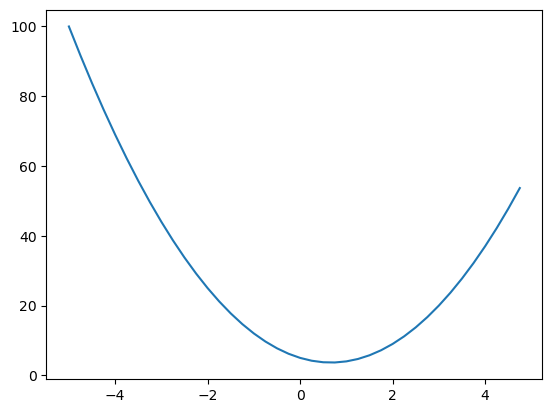

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.00000001
x=3.0
def der(x,h):
    return (f(x+h) - f(x))/h
c = 2/3

der(c,h)


0.0

In [6]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b +c
print(d)

4.0


In [7]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b +c
a+=h
d2 = a*b +c

print('d1',d1)
print('d2',d2)
print("slope",(d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [8]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data= data
        self._prev = set(_children)
        self._op = _op
        self.label=label
        self.grad=0.0
        self._backward = lambda : None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        other = other if isinstance(other,Value) else Value(other)
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    def __radd__(self,other):
        return self+other
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)

        out = Value(self.data*other.data,(self,other),'*')
        other = other if isinstance(other,Value) else Value(other)
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self,other):
        return self*other
    # we need to accumulate the gradients because duplicate objects will override the grad and will give out incorrect grad on backward pass
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) -1)/(math.exp(2*n)+1)
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self*-1
    
    def __sub__(self,other):
        return self+(-other)
    
    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out = Value(self.data**other,(self,),f'**{other}')
        def _backward():
            self.grad = (other)*(self.data**(other-1))*out.grad
        out._backward = _backward
        return out
        
    def exp(self):
        out  = Value(math.exp(self.data),(self,),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self*(other**-1)
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad=1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b;e.label='e'
d = e+c;d.label='d'
f = Value(-2.0,label='f')
L = f*d;L.label='L'

In [9]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [10]:
d._op

'+'

In [11]:
from graphviz import Digraph
def trace(root):
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format="svg",graph_attr={'rankdir':'LR'})

    nodes,edges=trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label="{%s | data %.4f | grad %.4f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    
    return dot

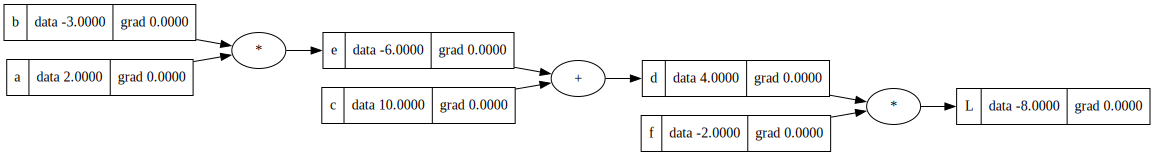

In [12]:
draw_dot(L)

L = d*f
dl/dd = f

(f(x+h) - f(x))/h

-> ((d+h)*f - d*f)/h
-> f


dL/dc=?
-> dL/dd * dd/dc
dd/dc = 1.0
dd/de = 1.0


dL/da = dL/dd * dd/de * de/da
e = a*b
de/da = b

In [13]:
L.grad=1
f.grad = d.data
d.grad = f.data

c.grad = d.grad
e.grad = d.grad

a.grad = b.data*e.grad
b.grad = a.data*e.grad



In [14]:
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*f.grad


e = a*b
d = e+c
L = f*d
L

Value(data=-7.286496)

In [15]:
def lol():
    h=0.01
    a = Value(2.0,label='a')
    b = Value(3.0,label='b')
    c = Value(5.0,label='c')
    e = a*b;e.label='e'
    d = e+c;d.label='d'
    f = Value(-2.0,label='f')
    L = f*d;L.label='L'
    L1 = L.data
    
    a = Value(2.0,label='a')
    b = Value(3.0,label='b')
    c = Value(5.0,label='c')
    e = a*b;e.label='e'
    d = e+c;d.label='d'
    d.data+=h
    f = Value(-2.0,label='f')
    L = f*d;L.label='L'
    L2 = L.data

    print((L2-L1)/h)

lol()
# all this is just gradient of L wrt d -> f

-1.9999999999999574


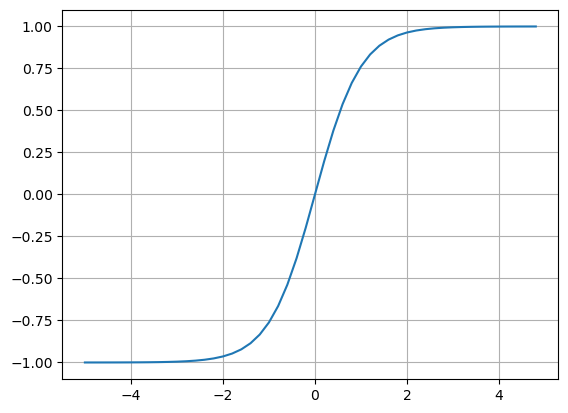

In [16]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [17]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias of the neuron
b = Value(6.8813735870195432,label='b')

x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2+b;n.label='n'
o = n.tanh();o.label='o'




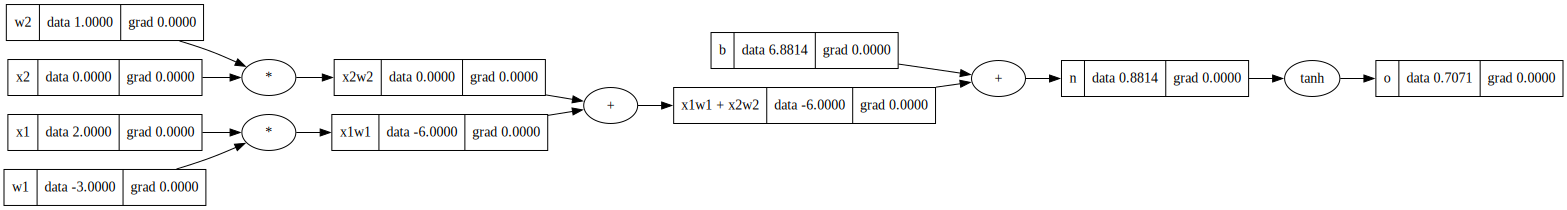

In [18]:
draw_dot(o)

In [19]:
o.backward()


# topological sort

In [20]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [21]:
o._grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()


In [22]:
o.grad=1.0
n.grad = 1 - o.data**2

x1w1x2w2.grad = n.grad
b.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

w1.grad = x1.data*x1w1.grad
w2.grad = x2.data*x2w2.grad


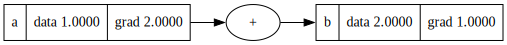

In [23]:
a = Value(1.0,label='a')
b = a + a;b.label='b'
b.backward()
draw_dot(b)

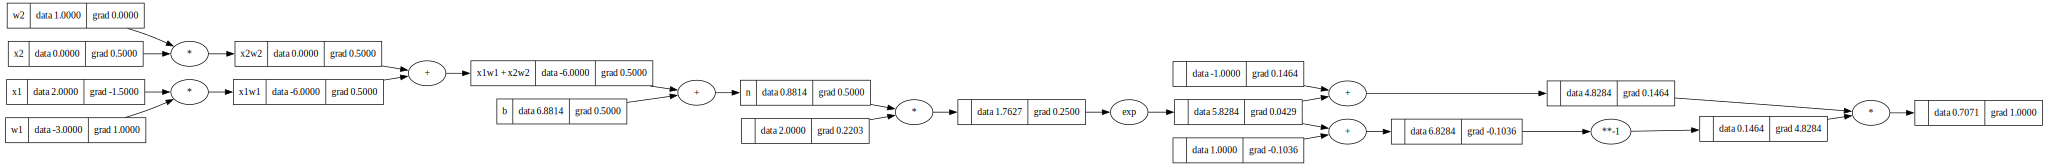

In [24]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias of the neuron
b = Value(6.8813735870195432,label='b')

x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2+b;n.label='n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.backward()
draw_dot(o)

In [25]:
import torch

x1 = torch.tensor([2.0],dtype = float,requires_grad=True)
x2 = torch.tensor([0.0],dtype = float,requires_grad=True)
w1 = torch.tensor([-3.0],dtype = float,requires_grad=True)
w2 = torch.tensor([1.0],dtype = float,requires_grad=True)
b = torch.tensor([6.8813735870195432],dtype = float,requires_grad=True)
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print(x2.grad.item())

0.7071067811865476
0.4999999999999999


In [26]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(np.random.uniform(-1,1))

    
    def __call__(self,x):
        act = sum((wi*xi for wi , xi in zip(self.w,x)), self.b)
        out  = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out)==1 else out
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [97]:
x = [2.0,3.0]
# n = Neuron(2)
# n = Layer(2,3)
n = MLP(3,[4,4,1])
n(x)

Value(data=0.09865445783553276)

In [28]:
n.parameters()

[Value(data=-0.7039952795321165),
 Value(data=-0.8759645066929329),
 Value(data=0.09837088058550925),
 Value(data=-0.5830874827310728),
 Value(data=-0.3973411143252039),
 Value(data=-0.36874336101155336),
 Value(data=-0.3420615295864524),
 Value(data=-0.08945953107552751),
 Value(data=0.11215167154217442),
 Value(data=-0.9936638664120878),
 Value(data=-0.34069287079117605),
 Value(data=-0.020411324483532445),
 Value(data=-0.568204078866885),
 Value(data=-0.7485292553885399),
 Value(data=0.3063743800019725),
 Value(data=0.6715040686975708),
 Value(data=-0.1412337064889151),
 Value(data=-0.6626793043440196),
 Value(data=-0.9038694440114543),
 Value(data=0.31557644340145674),
 Value(data=-0.2485213286079182),
 Value(data=0.6130770783569313),
 Value(data=-0.8489912600251286),
 Value(data=-0.5575607018760134),
 Value(data=-0.0671801097939011),
 Value(data=0.23024904368911403),
 Value(data=0.9401746419461672),
 Value(data=0.9815788096015909),
 Value(data=0.5135917931498446),
 Value(data=0.41

In [98]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
    ]
 
ys = [1.0,-1.0,-1.0,1.0]

In [118]:
for k in range(20):  
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))

    #backward pass
    for p in n.parameters():
        p.grad = 0.0
        
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05*p.grad

    print(k,loss.data)



0 0.0014339272539455545
1 0.0014294099616940549
2 0.0014249203993584206
3 0.001420458314779106
4 0.0014160234588284067
5 0.001411615585365275
6 0.001407234451190712
7 0.0014028798160041912
8 0.0013985514423607492
9 0.0013942490956288219
10 0.001389972543948831
11 0.0013857215581925479
12 0.0013814959119231006
13 0.0013772953813557009
14 0.001373119745319128
15 0.001368968785217727
16 0.001364842284994219
17 0.0013607400310930856
18 0.0013566618124245542
19 0.0013526074203292597


In [40]:
n.layers[0].neurons[0].w[0].grad

0.09028028241537266

In [41]:
n.layers[0].neurons[0].w[0].data

-0.7048980823562703

In [119]:
n.parameters()

[Value(data=-0.5788526783330215),
 Value(data=0.6107299975719339),
 Value(data=-0.6590726341142763),
 Value(data=-0.732045799294359),
 Value(data=-0.12672854181263185),
 Value(data=-0.7986812835358913),
 Value(data=-0.8123788780308151),
 Value(data=0.13117836781296704),
 Value(data=0.13120519970029992),
 Value(data=-0.4274554529355987),
 Value(data=0.552863414272966),
 Value(data=0.23031190148631656),
 Value(data=0.15634672562800236),
 Value(data=0.46310225872375066),
 Value(data=-1.0305524231966816),
 Value(data=-0.5877365753633621),
 Value(data=0.30659249754571466),
 Value(data=-0.1742512372773871),
 Value(data=0.690720154818168),
 Value(data=-0.5271140402707286),
 Value(data=0.584650982038439),
 Value(data=0.2432671411151271),
 Value(data=0.3275144575494411),
 Value(data=-0.1602091277420189),
 Value(data=1.2992854107243765),
 Value(data=0.02796605679044102),
 Value(data=-0.48657836435864676),
 Value(data=-0.2857181482037201),
 Value(data=0.10285380180903018),
 Value(data=-0.63142111

In [120]:
ypred

[Value(data=0.9887938801329346),
 Value(data=-0.984019161397691),
 Value(data=-0.9774153460190915),
 Value(data=0.9785156685004209)]

o = tanh(n)
do/dn = 1 - (tanh(n))^2 => 1 - o**2